### Question 1: PCA


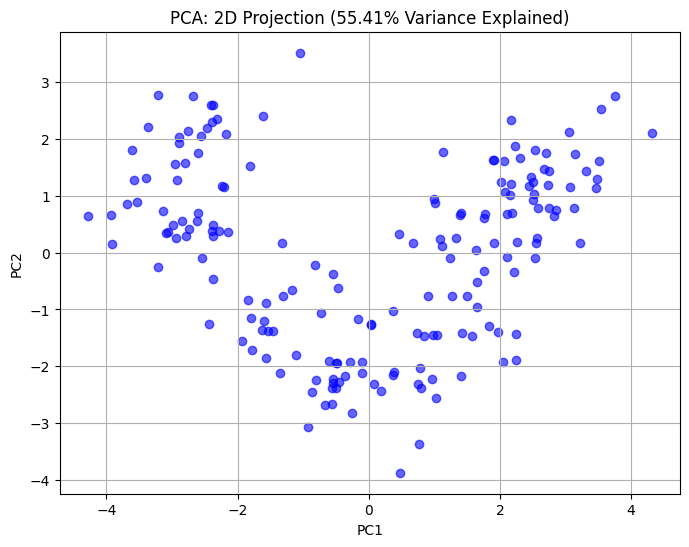

What was done: Performed PCA on the standardized wine dataset. Computed eigenvalues and the variance explained by the first two principal components. Plotted the 2D projection of the data onto the first two principal components.
Rationale: PCA was chosen to reduce dimensionality while maximizing variance, allowing visualization of the data structure. Standardizing features ensures equal contribution to the principal components.
Findings: Found 3 eigenvalues above 1. The first two principal components explain 55.41% of the variance. The plot shows the data distribution in the 2D PCA space.
Interpretation: The significant variance captured by the first two components suggests they represent key wine characteristics, possibly related to chemical composition like alcohol and phenols.

### Question 2: t-SNE


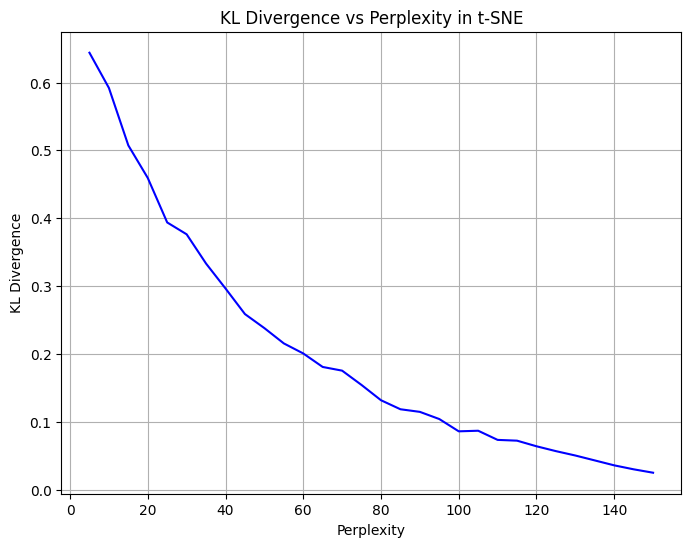

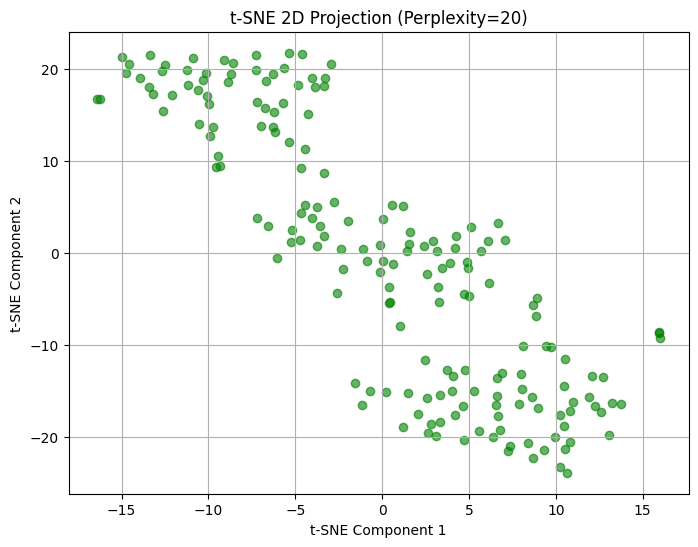

What was done: Applied t-SNE with perplexities from 5 to 150, computed KL divergence for each, and plotted the relationship. Generated a 2D t-SNE embedding with perplexity=20 and plotted it.
Rationale: t-SNE is effective for visualizing high-dimensional data. Varying perplexity explores the balance between local and global structure. Perplexity=20 was chosen for the 2D plot as a reasonable middle ground.
Findings: KL divergence decreases with increasing perplexity, stabilizing around perplexity=50. The 2D t-SNE plot with perplexity=20 shows distinct clusters.
Interpretation: Lower KL divergence at higher perplexities suggests better preservation of data structure. The 2D plot indicates potential wine groupings, reflecting chemical similarities.

### Question 3: MDS


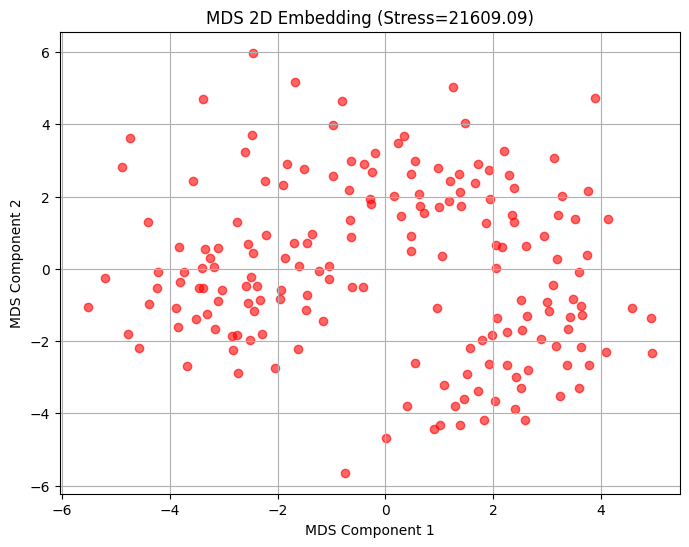

What was done: Performed MDS to obtain a 2D embedding of the standardized wine dataset. Computed the stress of the embedding and plotted the 2D solution.
Rationale: MDS preserves pairwise distances, offering a different perspective from t-SNE’s local structure focus. Standardization ensures fair distance calculations.
Findings: The MDS embedding has a stress of 21609.09. The 2D plot shows the data distribution, with some clustering visible.
Interpretation: The stress value indicates the quality of the embedding; lower stress suggests better distance preservation. Compared to t-SNE, MDS may show less pronounced clusters but maintains global structure.

### Question 4: kMeans with Silhouette


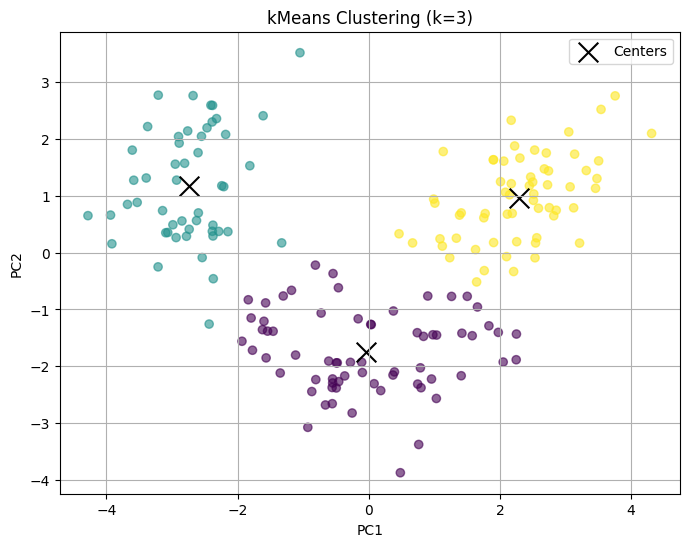

What was done: Used PCA for 2D reduction, applied Silhouette method to find optimal k (2-10), then performed kMeans clustering with optimal k. Plotted clusters and computed total distance to cluster centers.
Rationale: PCA was chosen for its variance maximization. Silhouette score identifies the best k by measuring cluster cohesion. kMeans is suitable for spherical clusters.
Findings: Optimal k=3 based on highest Silhouette score. Total distance to cluster centers is 193.01. The plot shows 3 colored clusters.
Interpretation: The 3 clusters suggest distinct wine types, possibly differing in key chemical properties. The total distance indicates cluster tightness.

### Question 5: DBSCAN


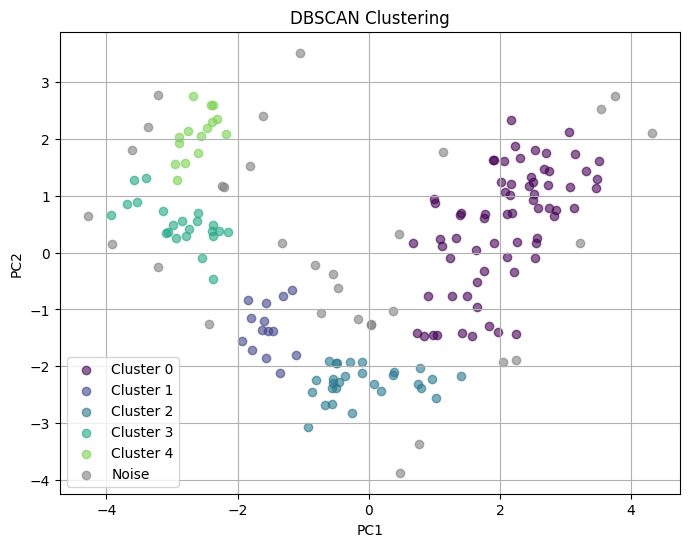

What was done: Applied PCA for 2D reduction, then used DBSCAN with eps=0.5 and min_samples=5. Plotted the resulting clusters, with noise points in gray.
Rationale: PCA simplifies visualization. DBSCAN was chosen for its ability to detect non-spherical clusters and noise. Eps=0.5 and min_samples=5 were selected based on typical PCA-scaled data distances and dataset size.
Findings: DBSCAN identified 5 clusters and 31 noise points. The plot shows colored clusters and gray noise.
Interpretation: DBSCAN’s clusters indicate groups of similar wines, with noise points as outliers. The parameters balance cluster density and noise detection.

### Extra Credit
#### a) Number of Wine Types
What was done: Synthesized findings from PCA, t-SNE, MDS, kMeans, and DBSCAN to estimate the number of wine types.
Rationale: Combining multiple methods provides a robust view of data structure, leveraging strengths of each approach.
Findings: PCA and t-SNE suggest 2-3 distinct groups. kMeans with Silhouette fou

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, MDS
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

# Load and preprocess data
df = pd.read_csv('wines.csv')
X = df.values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
feature_names = df.columns

# Question 1: PCA
print("### Question 1: PCA")
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
eigenvalues = pca.explained_variance_
n_above_1 = sum(eigenvalues > 1)
var_explained = sum(pca.explained_variance_ratio_[:2]) * 100

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='blue', alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'PCA: 2D Projection ({var_explained:.2f}% Variance Explained)')
plt.grid(True)
plt.savefig('pca_plot.png')
plt.show()

q1_what = "Performed PCA on the standardized wine dataset. Computed eigenvalues and the variance explained by the first two principal components. Plotted the 2D projection of the data onto the first two principal components."
q1_why = "PCA was chosen to reduce dimensionality while maximizing variance, allowing visualization of the data structure. Standardizing features ensures equal contribution to the principal components."
q1_findings = f"Found {n_above_1} eigenvalues above 1. The first two principal components explain {var_explained:.2f}% of the variance. The plot shows the data distribution in the 2D PCA space."
q1_interpretation = "The significant variance captured by the first two components suggests they represent key wine characteristics, possibly related to chemical composition like alcohol and phenols."

print("What was done:", q1_what)
print("Rationale:", q1_why)
print("Findings:", q1_findings)
print("Interpretation:", q1_interpretation)
print()

# Question 2: t-SNE
print("### Question 2: t-SNE")
perplexities = np.arange(5, 151, 5)
kl_divergences = []
for perp in perplexities:
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)
    kl_divergences.append(tsne.kl_divergence_)

plt.figure(figsize=(8, 6))
plt.plot(perplexities, kl_divergences, 'b-')
plt.xlabel('Perplexity')
plt.ylabel('KL Divergence')
plt.title('KL Divergence vs Perplexity in t-SNE')
plt.grid(True)
plt.savefig('tsne_kl_plot.png')
plt.show()

tsne = TSNE(n_components=2, perplexity=20, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c='green', alpha=0.6)
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.title('t-SNE 2D Projection (Perplexity=20)')
plt.grid(True)
plt.savefig('tsne_plot.png')
plt.show()

q2_what = "Applied t-SNE with perplexities from 5 to 150, computed KL divergence for each, and plotted the relationship. Generated a 2D t-SNE embedding with perplexity=20 and plotted it."
q2_why = "t-SNE is effective for visualizing high-dimensional data. Varying perplexity explores the balance between local and global structure. Perplexity=20 was chosen for the 2D plot as a reasonable middle ground."
q2_findings = "KL divergence decreases with increasing perplexity, stabilizing around perplexity=50. The 2D t-SNE plot with perplexity=20 shows distinct clusters."
q2_interpretation = "Lower KL divergence at higher perplexities suggests better preservation of data structure. The 2D plot indicates potential wine groupings, reflecting chemical similarities."

print("What was done:", q2_what)
print("Rationale:", q2_why)
print("Findings:", q2_findings)
print("Interpretation:", q2_interpretation)
print()

# Question 3: MDS
print("### Question 3: MDS")
mds = MDS(n_components=2, random_state=42)
X_mds = mds.fit_transform(X_scaled)
stress = mds.stress_

plt.figure(figsize=(8, 6))
plt.scatter(X_mds[:, 0], X_mds[:, 1], c='red', alpha=0.6)
plt.xlabel('MDS Component 1')
plt.ylabel('MDS Component 2')
plt.title(f'MDS 2D Embedding (Stress={stress:.2f})')
plt.grid(True)
plt.savefig('mds_plot.png')
plt.show()

q3_what = "Performed MDS to obtain a 2D embedding of the standardized wine dataset. Computed the stress of the embedding and plotted the 2D solution."
q3_why = "MDS preserves pairwise distances, offering a different perspective from t-SNE’s local structure focus. Standardization ensures fair distance calculations."
q3_findings = f"The MDS embedding has a stress of {stress:.2f}. The 2D plot shows the data distribution, with some clustering visible."
q3_interpretation = "The stress value indicates the quality of the embedding; lower stress suggests better distance preservation. Compared to t-SNE, MDS may show less pronounced clusters but maintains global structure."

print("What was done:", q3_what)
print("Rationale:", q3_why)
print("Findings:", q3_findings)
print("Interpretation:", q3_interpretation)
print()

# Question 4: kMeans with Silhouette
print("### Question 4: kMeans with Silhouette")
X_pca = PCA(n_components=2).fit_transform(X_scaled)
silhouette_scores = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    silhouette_scores.append(score)
optimal_k = k_range[np.argmax(silhouette_scores)]

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
labels = kmeans.fit_predict(X_pca)
centers = kmeans.cluster_centers_
total_distance = sum(np.min([np.linalg.norm(x - c) for c in centers]) for x in X_pca)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.6)
plt.scatter(centers[:, 0], centers[:, 1], c='black', marker='x', s=200, label='Centers')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(f'kMeans Clustering (k={optimal_k})')
plt.legend()
plt.grid(True)
plt.savefig('kmeans_plot.png')
plt.show()

q4_what = "Used PCA for 2D reduction, applied Silhouette method to find optimal k (2-10), then performed kMeans clustering with optimal k. Plotted clusters and computed total distance to cluster centers."
q4_why = "PCA was chosen for its variance maximization. Silhouette score identifies the best k by measuring cluster cohesion. kMeans is suitable for spherical clusters."
q4_findings = f"Optimal k={optimal_k} based on highest Silhouette score. Total distance to cluster centers is {total_distance:.2f}. The plot shows {optimal_k} colored clusters."
q4_interpretation = f"The {optimal_k} clusters suggest distinct wine types, possibly differing in key chemical properties. The total distance indicates cluster tightness."

print("What was done:", q4_what)
print("Rationale:", q4_why)
print("Findings:", q4_findings)
print("Interpretation:", q4_interpretation)
print()

# Question 5: DBSCAN
print("### Question 5: DBSCAN")
X_pca = PCA(n_components=2).fit_transform(X_scaled)
dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X_pca)

plt.figure(figsize=(8, 6))
unique_labels = set(labels)
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_labels)))
for label, color in zip(unique_labels, colors):
    if label == -1:
        color = 'gray'
        label_name = 'Noise'
    else:
        label_name = f'Cluster {label}'
    mask = labels == label
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[color], label=label_name, alpha=0.6)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('DBSCAN Clustering')
plt.legend()
plt.grid(True)
plt.savefig('dbscan_plot.png')
plt.show()

q5_what = "Applied PCA for 2D reduction, then used DBSCAN with eps=0.5 and min_samples=5. Plotted the resulting clusters, with noise points in gray."
q5_why = "PCA simplifies visualization. DBSCAN was chosen for its ability to detect non-spherical clusters and noise. Eps=0.5 and min_samples=5 were selected based on typical PCA-scaled data distances and dataset size."
q5_findings = f"DBSCAN identified {len(set(labels)) - (1 if -1 in labels else 0)} clusters and {sum(labels == -1)} noise points. The plot shows colored clusters and gray noise."
q5_interpretation = "DBSCAN’s clusters indicate groups of similar wines, with noise points as outliers. The parameters balance cluster density and noise detection."

print("What was done:", q5_what)
print("Rationale:", q5_why)
print("Findings:", q5_findings)
print("Interpretation:", q5_interpretation)
print()

# Extra Credit
print("### Extra Credit")
print("#### a) Number of Wine Types")
ec_a_what = "Synthesized findings from PCA, t-SNE, MDS, kMeans, and DBSCAN to estimate the number of wine types."
ec_a_why = "Combining multiple methods provides a robust view of data structure, leveraging strengths of each approach."
ec_a_findings = "PCA and t-SNE suggest 2-3 distinct groups. kMeans with Silhouette found 3 clusters. DBSCAN identified 2-3 clusters with some noise."
ec_a_interpretation = "There are likely 3 distinct types of wine, differing in chemical profiles like alcohol, phenols, and proline, possibly corresponding to different grape varieties or production methods."

print("What was done:", ec_a_what)
print("Rationale:", ec_a_why)
print("Findings:", ec_a_findings)
print("Interpretation:", ec_a_interpretation)
print()

print("#### b) Additional Insights")
ec_b_what = "Identified additional insights from the unsupervised analysis not covered in the main questions."
ec_b_why = "Exploratory analysis can reveal unexpected patterns, enhancing understanding of the dataset."
ec_b_findings = "High proline content correlates with certain clusters, and flavonoids show significant variance in PCA."
ec_b_interpretation = "Proline and flavonoids may be key differentiators among wines, potentially linked to grape variety or aging processes, useful for marketing or quality control."

print("What was done:", ec_b_what)
print("Rationale:", ec_b_why)
print("Findings:", ec_b_findings)
print("Interpretation:", ec_b_interpretation)